# The gallery, live: held-out scoring through the public API

Every number in this notebook is produced by a live fit. Nothing here reads
`analysis/results/*.csv`.

The path is always the same four steps, and it is the whole point of the notebook:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> kernels.forecast.align_panel(...)    # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

`02_transformer_vs_statistical.ipynb` reads the published retrospectives and tells the
research story over 152 cohorts. This notebook does the opposite: a small panel, one
cutoff, one field, and every step executed in front of you so the API and the
milestone-6 leaderboard semantics are visible rather than described.

**What it costs.** About 30-45 minutes of fitting on the dev box, dominated by
`compartmental` (a hierarchical ODE-style model at relaxed sampler settings) and
`guszcza_growth_curve`. The exact per-family timings are measured and printed in the
last cell.

**What it is not.** 25 cohorts at one cutoff on one field is a demonstration, not a
study. The evidence lives in the 200-company retrospectives
(`scripts/meyers_validation.py`, `scripts/compare_gallery.py`) and in notebook 02. The
closing section says explicitly what this notebook does and does not claim.

In [1]:
import datetime as dt
import logging
import platform
import sys
import time
import warnings
from pathlib import Path

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy.utils import get_logger as cmdstan_logger

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points
from ibnr.kernels.forecast import SCORE_DIRECTION, Absence, CohortForecast, align_panel
from ibnr.kernels.holdout import next_diagonal

warnings.filterwarnings("ignore")

# cmdstanpy installs its own INFO StreamHandler the first time a model is USED,
# which would override a level set at import time. Reaching for the logger
# through cmdstanpy's own accessor forces that setup to happen now, so the level
# sticks. Without this, guszcza_growth_curve and compartmental alone emit
# hundreds of init-rejection lines and the committed notebook is unreadable.
_lg = cmdstan_logger()
_lg.setLevel(logging.ERROR)
for _h in _lg.handlers:
    _h.setLevel(logging.ERROR)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- switches ---------------------------------------------------------------
RUN_COMPARTMENTAL = True  # ~13-20 min; the only high-variance line item
RUN_REPORTED_APPENDIX = True  # ~3 min; meyers_ccl / meyers_csr on reported_loss

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(1997, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@1997"
PREMIUM_FIELD = "earned_premium"
# See "why 1990-1997" below - this is load-bearing, not cosmetic.
ORIGINS = [dt.date(y, 1, 1) for y in range(1990, 1998)]
SEED_FIT = 11  # every sampler / bootstrap / torch init
SEED_DRAW = 7  # every predict_at() and predict() call

# --- provenance -------------------------------------------------------------
SOURCE = pinned_source()  # never resolves @latest, never calls gh
PUBLISH_ID = active_publish_id()
print("ibnr           ", ibnr.__version__)
print("python         ", sys.version.split()[0], platform.platform())
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", active_mart_path(SOURCE).name)

C:\Users\EthanKang\Projects\ibnr\.claude\worktrees\wf_a48fc834-432-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ibnr            0.5.0
python          3.12.13 Windows-11-10.0.26200-SP0
mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## The panel

Two mechanical screens, both re-derived below from the mart rather than pasted in.

1. **The milestone-3 / Meyers screen** (`scripts/meyers_validation.select_companies`,
   the monograph's Table A.1): CV of net earned premium, CV of the net/direct premium
   ratio, a complete 10x10 square, a premium and loss floor, and Meyers' one excluded
   group. Run on all four lines it passes 60 companies on two or more lines - the 152
   `(company, line)` pairs the milestone-3 study scored.

2. **An ODP positivity screen.** `england_verrall_odp` legitimately refuses a cohort
   with a negative paid increment: the over-dispersed Poisson quasi-likelihood is not
   defined there. That is a documented family limit, not a bug. Of the 152 pairs only
   some are clean, and only **10 companies are clean on every one of their screened
   lines**.

Selecting whole clean **companies** rather than clean **pairs** is deliberate. It keeps
ODP on the board with zero refusals, so every model is asked about exactly the same 25
cohorts (the cohort-data parity rule); and it leaves each company with two or more lines,
which is what the multiline appendix at the end needs.

The size range is wide on purpose: the largest cohort carries roughly ten million
(USD thousands) of mean earned premium and the smallest a few hundred, so the board is
not a study of one magnitude.

In [2]:
# scripts/ is not an installed package, so the screen is imported by path rather
# than copied - a copy would drift from the script that produced the published
# retrospectives, and then the panel would silently stop being the study's panel.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "scripts"))
from meyers_validation import MEYERS_LINES, select_companies  # noqa: E402

MART = active_mart_path(SOURCE)

t0 = time.perf_counter()
passing = {ln: set(select_companies(MART, ln, 10_000)["company_code"]) for ln in MEYERS_LINES}
by_company: dict[str, list[str]] = {}
for ln, codes in passing.items():
    for c in codes:
        by_company.setdefault(c, []).append(ln)
multiline = {c: sorted(ls) for c, ls in by_company.items() if len(ls) >= 2}
print({ln: len(v) for ln, v in passing.items()})
print(
    f"companies passing on >=2 lines: {len(multiline)}  pairs: {sum(map(len, multiline.values()))}"
)

# --- ODP positivity screen on the <=1997 training slice ----------------------
scan = load_schedule_p(SOURCE, lines=MEYERS_LINES, companies=sorted(multiline)).expr.execute()
scan["eval_date"] = pd.to_datetime(scan["eval_date"])
scan["origin_period"] = pd.to_datetime(scan["origin_period"])
paid_train = scan[
    (scan["field"] == FIELD)
    & (scan["eval_date"] <= pd.Timestamp(AS_OF))
    & (scan["origin_period"].dt.year.between(1988, 1997))
]
clean_pairs = set()
for key, g in paid_train.groupby(["company_code", "line_of_business"]):
    increments = [
        np.diff(np.r_[0.0, gg.sort_values("dev_lag")["value"].to_numpy()])
        for _, gg in g.groupby("origin_period")
    ]
    if all((inc >= 0).all() for inc in increments):
        clean_pairs.add(key)
print(f"pairs with no negative paid increment in the training slice: {len(clean_pairs)}")

PANEL = {c: ls for c, ls in sorted(multiline.items()) if all((c, ln) in clean_pairs for ln in ls)}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"screens took {time.perf_counter() - t0:.1f}s")

# Recorded, so a future gold publish that moves the panel is LOUD rather than a
# board that silently compares different insurers to the published one.
EXPECTED_PANEL = {
    "10022": ["commercial_auto", "private_passenger_auto"],
    "14044": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "1767": [
        "commercial_auto",
        "other_liability",
        "private_passenger_auto",
        "workers_compensation",
    ],
    "18767": ["commercial_auto", "workers_compensation"],
    "2003": ["other_liability", "private_passenger_auto"],
    "25275": ["commercial_auto", "private_passenger_auto"],
    "27022": ["commercial_auto", "private_passenger_auto"],
    "2712": ["commercial_auto", "workers_compensation"],
    "620": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "7080": ["commercial_auto", "private_passenger_auto", "workers_compensation"],
}
assert PANEL == EXPECTED_PANEL, f"panel moved under publish_id {PUBLISH_ID}: {PANEL}"
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
for c, ls in PANEL.items():
    print(f"  {c:>6}  {', '.join(ls)}")

{'commercial_auto': 63, 'private_passenger_auto': 60, 'workers_compensation': 52, 'other_liability': 56}
companies passing on >=2 lines: 60  pairs: 152


pairs with no negative paid increment in the training slice: 87
screens took 2.1s

10 companies, 25 cohorts, 4 lines
   10022  commercial_auto, private_passenger_auto
   14044  commercial_auto, other_liability, private_passenger_auto
    1767  commercial_auto, other_liability, private_passenger_auto, workers_compensation
   18767  commercial_auto, workers_compensation
    2003  other_liability, private_passenger_auto
   25275  commercial_auto, private_passenger_auto
   27022  commercial_auto, private_passenger_auto
    2712  commercial_auto, workers_compensation
     620  commercial_auto, other_liability, private_passenger_auto
    7080  commercial_auto, private_passenger_auto, workers_compensation


In [3]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 25 screened pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri = tri_all.filter(_keep)

# API FRICTION, and the notebook does not work without it. The mart carries three
# segments (company_code, company_name, line_of_business) but kernels.nn_contract
# treats company_name as a display column and drops it, so a pooled NN fit is keyed
# on two. entry.log_lik_at(cells) then resolves the cohort from cells.frame[segments]
# and raises "unknown segment column 'company_name'". Binding the cohort explicitly
# does not rescue it either - index_into refuses 3 key columns against a 2-column
# fit one level down. Dropping the display column BEFORE both fit() and
# next_diagonal() is the only thing that works, and it costs the Stan entries
# nothing (they accept either schema).
tri = tri.with_expr(tri.expr.drop("company_name"))
print("segments:", tri.segments)
print(f"{tri.count()} rows loaded in {time.perf_counter() - t0:.1f}s")

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_prem = _frame[
    (_frame["field"] == PREMIUM_FIELD) & (_frame["origin_period"].dt.year.between(1988, 1997))
]
_paid_latest = _frame[
    (_frame["field"] == FIELD)
    & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
    & (_frame["origin_period"].dt.year.between(1988, 1997))
]
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_1997")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
pairs_table.round(0)

segments: ['company_code', 'line_of_business']
35000 rows loaded in 0.2s



units: USD thousands


,company_code,line_of_business,mean_earned_premium,paid_at_1997
0,1767,private_passenger_auto,11765584.0,79798868.0
1,2003,private_passenger_auto,1748237.0,10647389.0
2,1767,commercial_auto,354380.0,1872675.0
3,1767,workers_compensation,290542.0,1434790.0
4,7080,workers_compensation,273816.0,1455264.0
5,1767,other_liability,241441.0,1409719.0
6,7080,private_passenger_auto,182566.0,978867.0
7,2712,workers_compensation,84604.0,443565.0
8,620,other_liability,71947.0,281325.0
9,2003,other_liability,64689.0,185699.0


## The held-out question

`kernels.holdout.next_diagonal(triangle, as_of=..., fields=..., origins=...)` answers
one question: **given a fit trained on everything visible at `as_of`, which cells is it
scored on?** The answer is the next calendar diagonal, one cohort at a time, with the
next development lag `D_next` read from the data rather than assumed. Cells the fit
could not have known about are excluded and the reason is counted, not dropped silently
(`new_origin`, `dev_beyond_trained`, ...).

Two choices below are load-bearing.

**`fields=["paid_loss", "reported_loss"]` for every cohort, even though the board is on
paid.** `compartmental` is a joint paid-and-outstanding model and needs both. Mixing
one-field and two-field `HoldoutCells` on the same panel makes `align_panel` raise -
the second field contributes its own exclusions, so two models end up disagreeing about
the exclusion census for the same cohort, which is `align_panel`'s way of saying they
were not asked the same question. Building every cohort's cells **once** with both
fields and passing `field="paid_loss"` explicitly to `log_lik_at`, `predict_at` and
`CohortForecast` is what keeps the census identical. So `n_cells` reads 14 while the
paid narrowing gives 7, and that is correct.

**`origins` restricted to 1990-1997.** With the full 1988-1997 square, the next diagonal
reaches development lag 120 - and at that depth the training data has fewer than two
context values, so the NN entries' per-development standardization *pins* the step and
`log_lik_at` refuses. Every one of the four NN entries would leave the ELPD column, for
every cohort, structurally. Restricting the scored origins pulls the deepest scored lag
back to 96, where the context exists. It is demonstrated live further down rather than
asserted. Note this narrows the **scored** diagonal: each entry is still fitted on its
cohort's whole `as_of` slice.

That leaves **7 held-out paid cells per cohort, 175 offered in total.** How many of
those each score actually rests on is decided later, by the intersection over that
score's own members - see "What the panel cost" below.

In [4]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        fields=[FIELD, "reported_loss"],  # both, so compartmental shares the census
        premium_field=PREMIUM_FIELD,
        origins=ORIGINS,
    )
print(f"25 x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())
_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

25 x next_diagonal in 12.7s

('10022', 'commercial_auto'): n_cells=14 (both fields), paid=7
as_of       1997-12-31
eval_date   1998-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 2, 'no_predecessor': 0}
paid cells per cohort: [7] | panel total: 175


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1991-01-01,96,1998-12-31,792.0,790.0,1061.0
1,10022,commercial_auto,paid_loss,1992-01-01,84,1998-12-31,626.0,623.0,1281.0
2,10022,commercial_auto,paid_loss,1993-01-01,72,1998-12-31,861.0,852.0,1393.0
3,10022,commercial_auto,paid_loss,1994-01-01,60,1998-12-31,842.0,806.0,1692.0
4,10022,commercial_auto,paid_loss,1995-01-01,48,1998-12-31,410.0,386.0,1371.0
5,10022,commercial_auto,paid_loss,1996-01-01,36,1998-12-31,331.0,252.0,1360.0
6,10022,commercial_auto,paid_loss,1997-01-01,24,1998-12-31,468.0,276.0,1652.0


## The roster: who can be scored on what

Milestone 6 splits a forecast into **two independent capabilities**, and the split is the
reason this board can be honest about entries with very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive **density** -> **ELPD**;
* `PredictsHeldout` -> `predict_at()` -> predictive **draws** -> **CRPS**.

An entry may have either, both, or neither, and the two are not redundant.
`england_verrall_odp` draws perfectly well but its over-dispersed Poisson
quasi-likelihood is only a density up to proportionality, so it has no ELPD ever.
`deterministic/mack`'s bootstrap has no stated observation model, same conclusion by a
different route. The roster below is built from the live registry, not typed out.

Three entries - `sur`, `copula_glm`, `nn_transformer_ml` - subclass **neither** mixin.
They cannot appear in either score column at all, so they get an ultimate-level appendix
at the end instead of a board row. That is a gap in the entries, not in the panel, and
the leaderboard would say so with the reason `scorer_not_implemented` if they were
handed to it.

In [5]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density (ELPD)": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density (ELPD)'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density (ELPD)'] & ~roster['draws (CRPS)']).sum()} neither"
)
roster

15 registered entries; 8 density, 12 draws, 3 neither


,entry,family,density (ELPD),draws (CRPS)
0,clark_growth_curve,bayesian,False,True
1,compartmental,bayesian,True,True
2,england_verrall_odp,bayesian,False,True
3,guszcza_growth_curve,bayesian,True,True
4,meyers_ccl,bayesian,True,True
5,meyers_csr,bayesian,True,True
6,mack,deterministic,False,True
7,deeptriangle,nn,True,True
8,mdn,nn,True,True
9,nn_transformer,nn,True,True


In [6]:
# The methods section, in one dict. Every entry on the board is fitted with
# exactly these arguments - nothing is tuned per cohort.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
    "clark": dict(growth_curve="loglogistic", method="cape_cod"),
    "meyers_ccl": dict(seed=SEED_FIT, parallel_chains=4),
    "meyers_csr": dict(seed=SEED_FIT, parallel_chains=4),
    "england_verrall_odp": dict(seed=SEED_FIT, parallel_chains=4),
    "clark_growth_curve": dict(seed=SEED_FIT, parallel_chains=4, growth_curve="loglogistic"),
    # 4x1000 rather than the entry's 4x2500 default: the same estimand at a
    # smaller Monte Carlo budget, which saves ~7 min on this panel. min_ess_kish
    # on the board is what makes the cost of that visible.
    "guszcza_growth_curve": dict(
        seed=SEED_FIT, parallel_chains=4, iter_sampling=1000, iter_warmup=1000
    ),
}
# mack and clark are the two entries whose fit() takes NO seed - they are a
# deterministic estimator and an MLE, and the randomness is in predict()/predict_at().
COMPARTMENTAL_CONFIG = dict(
    variant="lognormal",  # the better-calibrated arm on paid in the milestone-4 retro
    seed=SEED_FIT,
    parallel_chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    # kernels.harness stage-1 relaxation, NOT the monograph's 0.99 / 15: worth
    # about 4x per cohort and documented as such in the model card.
    target_accept=0.9,
    max_treedepth=12,
)
# The NN entries fit ONCE, pooled over the whole 25-cohort panel, then predict per
# cohort. 120 epochs / 5 ensemble members is the demonstrative cut of the published
# study's 400 epochs - see the closing caveats.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)

pd.DataFrame(
    [{"entry": k, "how": "per cohort", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": "compartmental", "how": "per cohort", "config": str(COMPARTMENTAL_CONFIG)}]
    + [
        {"entry": n, "how": "pooled fit", "config": str(NN_CONFIG)}
        for n in ["nn_transformer", "mdn", "resnet", "deeptriangle"]
    ]
)

,entry,how,config
0,mack,per cohort,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,clark,per cohort,"{'growth_curve': 'loglogistic', 'method': 'cap..."
2,meyers_ccl,per cohort,"{'seed': 11, 'parallel_chains': 4}"
3,meyers_csr,per cohort,"{'seed': 11, 'parallel_chains': 4}"
4,england_verrall_odp,per cohort,"{'seed': 11, 'parallel_chains': 4}"
5,clark_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'growth_cur..."
6,guszcza_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'iter_sampl..."
7,compartmental,per cohort,"{'variant': 'lognormal', 'seed': 11, 'parallel..."
8,nn_transformer,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
9,mdn,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."


In [7]:
# Stan compilation is a one-off cost that has nothing to do with sampling speed,
# so it is paid here and timed separately. On a warm checkout this is ~0s; on a
# cold one it is a few minutes and the fit timings below stay honest either way.
compile_seconds = {}
for name in [
    "meyers_ccl",
    "meyers_csr",
    "england_verrall_odp",
    "clark_growth_curve",
    "guszcza_growth_curve",
    *(["compartmental"] if RUN_COMPARTMENTAL else []),
]:
    t0 = time.perf_counter()
    gallery.get(name).precompile()
    compile_seconds[name] = round(time.perf_counter() - t0, 1)
print("precompile seconds:", compile_seconds)

precompile seconds: {'meyers_ccl': 0.3, 'meyers_csr': 0.3, 'england_verrall_odp': 0.3, 'clark_growth_curve': 0.2, 'guszcza_growth_curve': 0.2, 'compartmental': 0.5}


### The helper

This is the API surface the notebook exists to show, so it is written out rather than
hidden in a module. Note `Absence`: a missing array is never a bare `None`, because the
board has to distinguish "this entry has no density, ever" from "this run refused this
cohort". The vocabulary is closed - `fit_failed`, `no_cell_sampler`,
`no_predictive_density`, `not_offered`, `scorer_not_implemented`, `scoring_refused` -
and free text raises.

In [8]:
refusals: list[dict] = []
point_rows: list[dict] = []


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: the quasi-likelihood / bootstrap entries.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Ultimate-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs to 2007 and an unrestricted
    aggregate is silently ~2.4x inflated (a gotcha that has bitten this repo).
    """
    is_nn = gallery.get(name).family == "nn"
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW) if is_nn else entry.predict(seed=SEED_DRAW)
    outcome = (
        entry.realized_ultimates(sub[key], segment=seg)
        if is_nn
        else entry.realized_ultimates(sub[key])
    )
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    return dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [9]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the
        # entry: 175 live fits, each Stan one carrying a 10,000-draw
        # InferenceData, does not fit in memory.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.1f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                       6.5s  (0.3s per cohort)


clark                     16.2s  (0.6s per cohort)


meyers_ccl                72.6s  (2.9s per cohort)


meyers_csr                73.1s  (2.9s per cohort)


england_verrall_odp       61.4s  (2.5s per cohort)


clark_growth_curve        66.6s  (2.7s per cohort)


guszcza_growth_curve     311.1s  (12.4s per cohort)



refusals so far: 2
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'draws', 'error': "ValueError('lam value too large')"}
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'ultimate', 'error': "ValueError('lam value too large')"}


In [10]:
if RUN_COMPARTMENTAL:
    t0 = time.perf_counter()
    for i, key in enumerate(COHORTS, 1):
        t1 = time.perf_counter()
        entry, absent = fit_or_absent("compartmental", key, **COMPARTMENTAL_CONFIG)
        if entry is None:
            forecasts.append(absent)
        else:
            forecasts.append(forecast_for("compartmental", entry, key))
            record_point("compartmental", entry, key)
            del entry
        print(
            f"  [{i:2d}/{len(COHORTS)}] {key[0]:>6} {key[1]:<24} {time.perf_counter() - t1:6.1f}s",
            flush=True,
        )
    fit_seconds["compartmental"] = round(time.perf_counter() - t0, 1)
    print(
        f"\ncompartmental {fit_seconds['compartmental']:.1f}s "
        f"({fit_seconds['compartmental'] / len(COHORTS):.1f}s per cohort)"
    )
else:
    print("compartmental skipped (RUN_COMPARTMENTAL = False)")

  [ 1/25]  10022 commercial_auto            15.9s


  [ 2/25]  10022 private_passenger_auto     15.9s


  [ 3/25]  14044 commercial_auto             9.8s


  [ 4/25]  14044 other_liability            12.6s


  [ 5/25]  14044 private_passenger_auto     11.3s


...

  [22/25]    620 private_passenger_auto     15.1s


  [23/25]   7080 commercial_auto            37.4s


  [24/25]   7080 private_passenger_auto     39.4s


  [25/25]   7080 workers_compensation       49.7s



compartmental 686.1s (27.4s per cohort)


In [11]:
from ibnr.gallery.nn.deeptriangle import DeepTriangleConfig
from ibnr.gallery.nn.mdn import MDNConfig
from ibnr.gallery.nn.resnet import ResNetConfig
from ibnr.gallery.nn.transformer import TransformerConfig

# One pooled fit per entry over the WHOLE panel triangle, then 25 cohort
# forecasts off it. The cost therefore amortizes, and the clustering unit for
# any paired test on these rows is the FIT (the whole panel), not the cohort.
NN_ENTRIES = {
    "nn_transformer": TransformerConfig,
    "mdn": MDNConfig,
    "resnet": ResNetConfig,
    "deeptriangle": DeepTriangleConfig,
}
nn_fits = {}
for name, ConfigCls in NN_ENTRIES.items():
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring 25 cohorts)",
        flush=True,
    )

nn_transformer            77.3s  (pooled fit 56.0s + 21.3s scoring 25 cohorts)


mdn                       18.8s  (pooled fit 11.0s + 7.8s scoring 25 cohorts)


resnet                    27.2s  (pooled fit 17.6s + 9.6s scoring 25 cohorts)


deeptriangle              46.0s  (pooled fit 30.9s + 15.1s scoring 25 cohorts)


### Why the scored origins stop at 1990, demonstrated

The claim above was that scoring the full 1988-1997 square would take the whole NN family
out of the ELPD column. Here it is, live: the same fitted `mdn`, the same cohort, cells
built over origins 1988-1997 instead.

In [12]:
_deep_cells = next_diagonal(
    sub[COHORTS[0]],
    as_of=AS_OF,
    fields=[FIELD, "reported_loss"],
    premium_field=PREMIUM_FIELD,
    origins=[dt.date(y, 1, 1) for y in range(1988, 1998)],
)
print(
    f"origins 1988-1997 -> {(_deep_cells.frame['field'] == FIELD).sum()} paid cells "
    f"(vs {(cells[COHORTS[0]].frame['field'] == FIELD).sum()} on the panel), "
    f"deepest dev_lag {_deep_cells.frame['dev_lag'].max()}"
)
try:
    nn_fits["mdn"].log_lik_at(_deep_cells, field=FIELD)
    print("scored - the restriction is no longer needed, revisit ORIGINS")
except Exception as exc:
    print(f"\nmdn.log_lik_at refuses: {type(exc).__name__}\n  {exc}")
print(
    "\ndraws are fine at that depth:",
    nn_fits["mdn"].predict_at(_deep_cells, field=FIELD, seed=SEED_DRAW).shape,
)

origins 1988-1997 -> 9 paid cells (vs 7 on the panel), deepest dev_lag 120

mdn.log_lik_at refuses: ValueError
  1 cell(s) sit at pinned dev step(s) [10]: fewer than two training-context values reached the per-dev normalizer there, so the MDN head is untrained and its scale is degenerate. mdn refuses to score a density at a pinned dev; the cells remain CRPS-scorable via predict_at, where a pinned draw is the pooled dev mean

draws are fine at that depth: (500, 9)


In [13]:
panel = align_panel(forecasts, units=tri.meta.units)
print(repr(panel))
print()
print(
    f"ELPD panel: {panel.n_cells_for('elpd'):4d} cells over "
    f"{panel.n_cohorts_for('elpd')} cohorts | members {list(panel.elpd_members)}"
)
print(f"            fingerprint {panel.elpd_fingerprint}")
print(
    f"CRPS panel: {panel.n_cells_for('crps'):4d} cells over "
    f"{panel.n_cohorts_for('crps')} cohorts | members {list(panel.crps_members)}"
)
print(f"            fingerprint {panel.crps_fingerprint}")
print(f"union of the two panels: {panel.n_cells} cells")

ForecastPanel(paid_loss@1997 @ 1997-12-31, 12 models, 24 cohorts | elpd: 126 cells over ['compartmental', 'deeptriangle', 'guszcza_growth_curve', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet'] | crps: 168 cells over ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet'] | dropped=56)

ELPD panel:  126 cells over 18 cohorts | members ['compartmental', 'deeptriangle', 'guszcza_growth_curve', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet']
            fingerprint 0bd1e6212c5c56f2
CRPS panel:  168 cells over 24 cohorts | members ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet']
            fingerprint 468d769145503ba4
union of the two panels: 168 cells


## How to read the board

* **ELPD is higher-is-better, CRPS is lower-is-better.** They point in opposite
  directions, which is why `SCORE_DIRECTION` is machine-readable and why `leaderboard()`
  has **no default sort and no `sort_by=`**: an average-rank column across two columns
  running opposite ways is nonsense, and the board refuses to invite one.
* **A missing score is `pd.NA`, never `0.0`.** On this board a pointwise ELPD is about
  -10 nats, so imputing 0 would credit a model that was never scored with more than the
  entire plausible gap between two real models - and 0.0 is simultaneously the best ELPD
  and the best CRPS there is. Every total is reduced in Python from the model's own
  array, because `groupby().sum()` over an all-missing group returns 0.0 in pandas.
* **The two columns can rest on different cells.** Each score's panel is the
  intersection over the models eligible for *that* score, so the board has
  `n_cells_elpd` and `n_cells_crps` and never a bare `n_cells`. Each column carries its
  own member list and its own fingerprint, stamped on every row: the number carries the
  set that produced it.
* **`elpd_status`** distinguishes `scored` from `na: no_predictive_density` (permanent,
  about the entry) and from a run-level gap.
* **`n_cells_zero_density`** counts cells where every posterior draw gave the outcome
  zero density. Those propagate as `-inf` rather than being dropped - a model that
  assigned zero probability to something that happened should rank last, not escape.
* **`min_ess_kish`** is the effective number of draws behind the worst cell's density,
  and **`n_draws_density_min`** the raw draw count. Watch these on the NN rows: their
  density averages over the ensemble members, so 5 members means 5 draws against Stan's
  10,000. The number is the same estimand; its Monte Carlo error is not.

In [14]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_elpd",
        "elpd",
        "elpd_per_cell",
        "elpd_status",
        "n_cells_zero_density",
        "min_ess_kish",
        "n_draws_density_min",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("SCORE_DIRECTION:", SCORE_DIRECTION)
view.sort_values("crps_per_cell").round(3)

SCORE_DIRECTION: {'elpd': 'higher_is_better', 'elpd_per_cell': 'higher_is_better', 'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,n_draws_density_min,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
9,meyers_csr,24,126,-1138.175,-9.033,scored,0,3025.853,10000,168,505375.965,3008.19,10000
6,mack,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,672793.041,4004.72,10000
2,compartmental,24,126,-1100.573,-8.735,scored,0,30.487,4000,168,703878.124,4189.751,4000
3,deeptriangle,24,126,-1129.389,-8.963,scored,0,1.002,5,168,727674.68,4331.397,500
4,england_verrall_odp,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,750013.2,4464.364,10000
11,resnet,24,126,-1202.551,-9.544,scored,0,1.0,5,168,827316.782,4924.505,500
8,meyers_ccl,24,126,-1150.311,-9.129,scored,0,1555.452,10000,168,904702.45,5385.134,10000
7,mdn,24,126,-1153.506,-9.155,scored,0,1.198,5,168,1028121.542,6119.771,500
0,clark,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1370670.308,8158.752,10000
1,clark_growth_curve,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1376627.112,8194.209,10000


In [15]:
# The full board, including the member lists and fingerprints every published
# number has to carry.
board

,task,as_of,model,n_cohorts,elpd_members,elpd_fingerprint,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,crps_members,crps_fingerprint,n_cells_crps,crps,crps_per_cell,crps_status,n_draws_density_min,n_draws_sample_min,n_cells_elpd_own,n_cells_elpd_dropped,n_cells_crps_own,n_cells_crps_dropped
0,paid_loss@1997,1997-12-31,clark,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1370670.307882,8158.751833,scored,<NA>,10000,0,0,168,0
1,paid_loss@1997,1997-12-31,clark_growth_curve,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1376627.111758,8194.208999,scored,<NA>,10000,0,0,175,7
2,paid_loss@1997,1997-12-31,compartmental,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1100.572852,-8.734705,scored,0,30.486582,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,703878.124107,4189.750739,scored,4000,4000,126,0,175,7
3,paid_loss@1997,1997-12-31,deeptriangle,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1129.388592,-8.963402,scored,0,1.001645,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,727674.679743,4331.396903,scored,5,500,175,49,175,7
4,paid_loss@1997,1997-12-31,england_verrall_odp,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,750013.200262,4464.364287,scored,<NA>,10000,0,0,175,7
5,paid_loss@1997,1997-12-31,guszcza_growth_curve,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1217.540315,-9.663018,scored,0,235.720538,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,2556031.26639,15214.471824,scored,4000,4000,175,49,175,7
6,paid_loss@1997,1997-12-31,mack,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,672793.041333,4004.720484,scored,<NA>,10000,0,0,175,7
7,paid_loss@1997,1997-12-31,mdn,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1153.505965,-9.154809,scored,0,1.198034,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1028121.542022,6119.771083,scored,5,500,175,49,175,7
8,paid_loss@1997,1997-12-31,meyers_ccl,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1150.311038,-9.129453,scored,0,1555.452068,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,904702.449537,5385.133628,scored,10000,10000,175,49,175,7
9,paid_loss@1997,1997-12-31,meyers_csr,24,"compartmental,deeptriangle,guszcza_growth_curv...",0bd1e6212c5c56f2,126,-1138.174678,-9.033132,scored,0,3025.852567,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,505375.964535,3008.190265,scored,10000,10000,175,49,175,7


## What the panel cost

`panel.dropped` names every cell a member offered and the panel could not use, and which
member lacked it. `panel.absences` is the census behind every N/A. `panel.coverage` says
what each model offered and what survived. This is the milestone-6 design working: a
member that refuses one cohort removes that cohort from **that score's** panel for every
other member of that score - and from that score only.

In [16]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped)
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())
print("\nrun-level refusals recorded by the helper:", len(refusals))
for r in refusals:
    print("  ", r["model"], r["cohort"], r["axis"], "->", r["error"][:160])
display(panel.coverage)
display(
    panel.absences.groupby(["model", "axis", "reason", "scope"], as_index=False).agg(
        cohorts=("cohort", "nunique"), cells=("n_cells", "sum")
    )
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 56


,score,task,as_of,company_code,line_of_business,field,origin_period,dev_lag,missing_from
0,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1991-01-01,96,"(compartmental,)"
1,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1992-01-01,84,"(compartmental,)"
2,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1993-01-01,72,"(compartmental,)"
3,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1994-01-01,60,"(compartmental,)"
4,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1995-01-01,48,"(compartmental,)"
5,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1996-01-01,36,"(compartmental,)"
6,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1997-01-01,24,"(compartmental,)"
7,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1991-01-01,96,"(compartmental,)"
8,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1992-01-01,84,"(compartmental,)"
9,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1993-01-01,72,"(compartmental,)"



dropped by score: {'elpd': 49, 'crps': 7}

run-level refusals recorded by the helper: 9
   clark ('27022', 'commercial_auto') draws -> ValueError('lam value too large')
   clark ('27022', 'commercial_auto') ultimate -> ValueError('lam value too large')
   compartmental ('10022', 'private_passenger_auto') density -> ValueError('1 cell(s) have a non-positive outstanding level or paid increment; the lognormal variant has no density there - the same family limit _lognormal_sta
   compartmental ('14044', 'commercial_auto') density -> ValueError('1 cell(s) have a non-positive outstanding level or paid increment; the lognormal variant has no density there - the same family limit _lognormal_sta
   compartmental ('14044', 'other_liability') density -> ValueError('2 cell(s) have a non-positive outstanding level or paid increment; the lognormal variant has no density there - the same family limit _lognormal_sta
   compartmental ('14044', 'private_passenger_auto') density -> ValueError('1 cell(s)

,model,n_cohorts_offered,is_elpd_member,elpd_status,n_cohorts_elpd,n_cells_elpd_own,n_cells_elpd_on_panel,n_cells_elpd_dropped,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,clark,25,False,na: no_predictive_density,0,0,0,0,True,scored,24,168,168,0
1,clark_growth_curve,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
2,compartmental,25,True,scored,18,126,126,0,True,scored,25,175,168,7
3,deeptriangle,25,True,scored,25,175,126,49,True,scored,25,175,168,7
4,england_verrall_odp,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
5,guszcza_growth_curve,25,True,scored,25,175,126,49,True,scored,25,175,168,7
6,mack,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
7,mdn,25,True,scored,25,175,126,49,True,scored,25,175,168,7
8,meyers_ccl,25,True,scored,25,175,126,49,True,scored,25,175,168,7
9,meyers_csr,25,True,scored,25,175,126,49,True,scored,25,175,168,7


,model,axis,reason,scope,cohorts,cells
0,clark,density,no_predictive_density,model,25,175
1,clark,draws,scoring_refused,cohort,1,7
2,clark_growth_curve,density,no_predictive_density,model,25,175
3,compartmental,density,scoring_refused,cohort,7,49
4,england_verrall_odp,density,no_predictive_density,model,25,175
5,mack,density,no_predictive_density,model,25,175


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,2,0,7
1,"(10022, private_passenger_auto)",0,2,0,7
2,"(14044, commercial_auto)",0,2,0,7
3,"(14044, other_liability)",0,2,0,7
4,"(14044, private_passenger_auto)",0,2,0,7
5,"(1767, commercial_auto)",0,2,0,7
6,"(1767, other_liability)",0,2,0,7
7,"(1767, private_passenger_auto)",0,2,0,7
8,"(1767, workers_compensation)",0,2,0,7
9,"(18767, commercial_auto)",0,2,0,7


## Per cohort, and whether one cohort is driving the ranking

`panel.by_cohort` is one row per (model, cohort). Paired differences against a single
reference model are the honest way to read it: a leaderboard total is extensive, so a
model that happens to be good on the two biggest cohorts wins the sum outright.

One caveat that the panel object cannot enforce. The four NN entries are **one pooled fit
each** across the whole panel, so their 25 cohort rows are not independent replicates -
the clustering unit for those models is the fit, not the cohort. A sign test over cohorts
is therefore a description of this board, not an inferential claim about the entries.

In [17]:
from scipy.stats import binomtest

REFERENCE = "meyers_csr"
bc = panel.by_cohort.copy()
bc["cohort"] = bc["cohort"].map(lambda t: f"{t[0]}/{t[1][:16]}")
# by_cohort carries pd.NA for "this model has no score here", so the column is
# object dtype - coerce for the pivot, but to NaN and never to 0.0.
bc["elpd"] = pd.to_numeric(bc["elpd"], errors="coerce")
wide = bc.pivot_table(index="cohort", columns="model", values="elpd", dropna=False)
wide = wide.dropna(axis=1, how="all")
display(wide.round(1))

diff = wide.sub(wide[REFERENCE], axis=0).drop(columns=[REFERENCE])
summary = pd.DataFrame(
    {
        "mean_elpd_diff": diff.mean(),
        "median_elpd_diff": diff.median(),
        "cohorts_better": (diff > 0).sum(),
        "cohorts_worse": (diff < 0).sum(),
        "worst_single_cohort": diff.min(),
        "best_single_cohort": diff.max(),
    }
)
summary["sign_test_p"] = [
    binomtest(int((diff[c] > 0).sum()), int(diff[c].notna().sum())).pvalue for c in diff.columns
]
print(f"pointwise ELPD difference vs {REFERENCE}, per cohort (positive = better than {REFERENCE})")
summary.round(3)

model,compartmental,deeptriangle,guszcza_growth_curve,mdn,meyers_ccl,meyers_csr,nn_transformer,resnet
cohort,,,,,,,,
10022/commercial_auto,-30.6,-30.5,-40.9,-32.1,-40.1,-39.8,-32.4,-32.6
10022/private_passenge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14044/commercial_auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14044/other_liability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14044/private_passenge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1767/commercial_auto,-73.6,-67.4,-73.2,-67.6,-68.5,-66.7,-70.3,-67.4
1767/other_liability,-70.3,-73.5,-80.3,-73.1,-77.5,-76.4,-78.3,-72.8
1767/private_passenge,-83.1,-88.5,-102.5,-90.8,-92.4,-89.6,-96.2,-90.8
1767/workers_compensa,-67.3,-67.3,-74.7,-72.9,-66.7,-66.9,-71.2,-66.8


pointwise ELPD difference vs meyers_csr, per cohort (positive = better than meyers_csr)


,mean_elpd_diff,median_elpd_diff,cohorts_better,cohorts_worse,worst_single_cohort,best_single_cohort,sign_test_p
model,,,,,,,
compartmental,2.089,3.765,13,5,-10.273,9.145,0.096
deeptriangle,0.488,1.193,12,6,-29.060,9.253,0.238
guszcza_growth_curve,-4.409,-3.754,1,17,-16.094,0.342,0.000
mdn,-0.852,-1.120,8,10,-13.902,7.681,0.815
meyers_ccl,-0.674,-0.550,7,11,-2.943,1.099,0.481
nn_transformer,-2.904,-2.712,5,13,-29.283,7.315,0.096
resnet,-3.576,1.108,11,7,-92.397,7.197,0.481


## Ultimate-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the
model actually delivers: the predicted ultimate against what the later statements
revealed. Every row below comes from `entry.predict()` and `entry.realized_ultimates()`
on the same fits used above - `realized_ultimates` restricts to the origins the training
slice had, which is what keeps the mart's post-1997 accident years out of the aggregate.

In [18]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the
# number a reserving audience reads, and it is NOT the mean of the per-cohort
# percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
deeptriangle,25,1.13,3.23,37.00,2.30
compartmental,25,1.01,3.54,25.95,0.70
mack,25,2.53,4.70,15.77,1.57
resnet,25,1.98,4.87,26.20,4.55
mdn,25,3.93,4.89,8.20,4.47
meyers_csr,25,1.20,5.44,36.76,-0.34
nn_transformer,25,2.66,6.38,26.00,7.68
meyers_ccl,25,3.54,6.77,9.92,3.08
england_verrall_odp,25,3.58,6.81,7.84,1.71


model,clark,clark_growth_curve,compartmental,deeptriangle,england_verrall_odp,guszcza_growth_curve,mack,mdn,meyers_ccl,meyers_csr,nn_transformer,resnet
line_of_business,,,,,,,,,,,,
commercial_auto,7.6,6.8,2.6,-0.1,12.1,14.1,5.9,1.4,5.8,3.1,2.5,4.9
other_liability,5.1,6.4,-3.4,-7.8,6.1,11.3,2.0,1.9,12.7,3.6,-3.4,-4.7
private_passenger_auto,4.8,4.9,0.7,1.4,1.2,5.6,1.0,3.8,1.6,-0.3,3.3,3.9
workers_compensation,7.9,8.2,2.4,2.7,1.8,2.8,1.6,4.8,2.5,-0.5,2.2,0.6


## Calibration on the held-out cells

The PIT of a held-out cell is the fraction of predictive draws at or below the outcome.
If the predictive distribution is right, PITs are Uniform(0, 1). `ks_uniformity` is the
same two-sided KS test the Meyers retrospectives report (as `D x 100`, with an asterisk
when it fails at 5%), applied here to the CRPS panel's cells rather than to ultimates.

In [19]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    collected.setdefault(f.model, []).append(p[on])
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks_rows = []
for m, p in pits.items():
    r = ks_uniformity(p)
    ks_rows.append(
        {
            "model": m,
            "n": r.n,
            "D x 100": 100 * r.statistic,
            "critical 5% x 100": 100 * r.critical_value_5pct,
            "p_value": r.p_value,
            "passes": not r.reject_5pct,
            "mean_pit": float(p.mean()),
        }
    )
ks = pd.DataFrame(ks_rows).sort_values("D x 100").reset_index(drop=True)
ks.round(3)

,model,n,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,nn_transformer,168,11.038,10.493,0.033,False,0.443
1,england_verrall_odp,168,13.615,10.493,0.004,False,0.423
2,resnet,168,14.438,10.493,0.002,False,0.420
3,meyers_csr,168,14.739,10.493,0.001,False,0.482
4,compartmental,168,14.952,10.493,0.001,False,0.421
5,deeptriangle,168,15.029,10.493,0.001,False,0.418
6,mdn,168,16.429,10.493,0.000,False,0.405
7,meyers_ccl,168,20.010,10.493,0.000,False,0.423
8,mack,168,20.665,10.493,0.000,False,0.392
9,clark,168,23.149,10.493,0.000,False,0.357


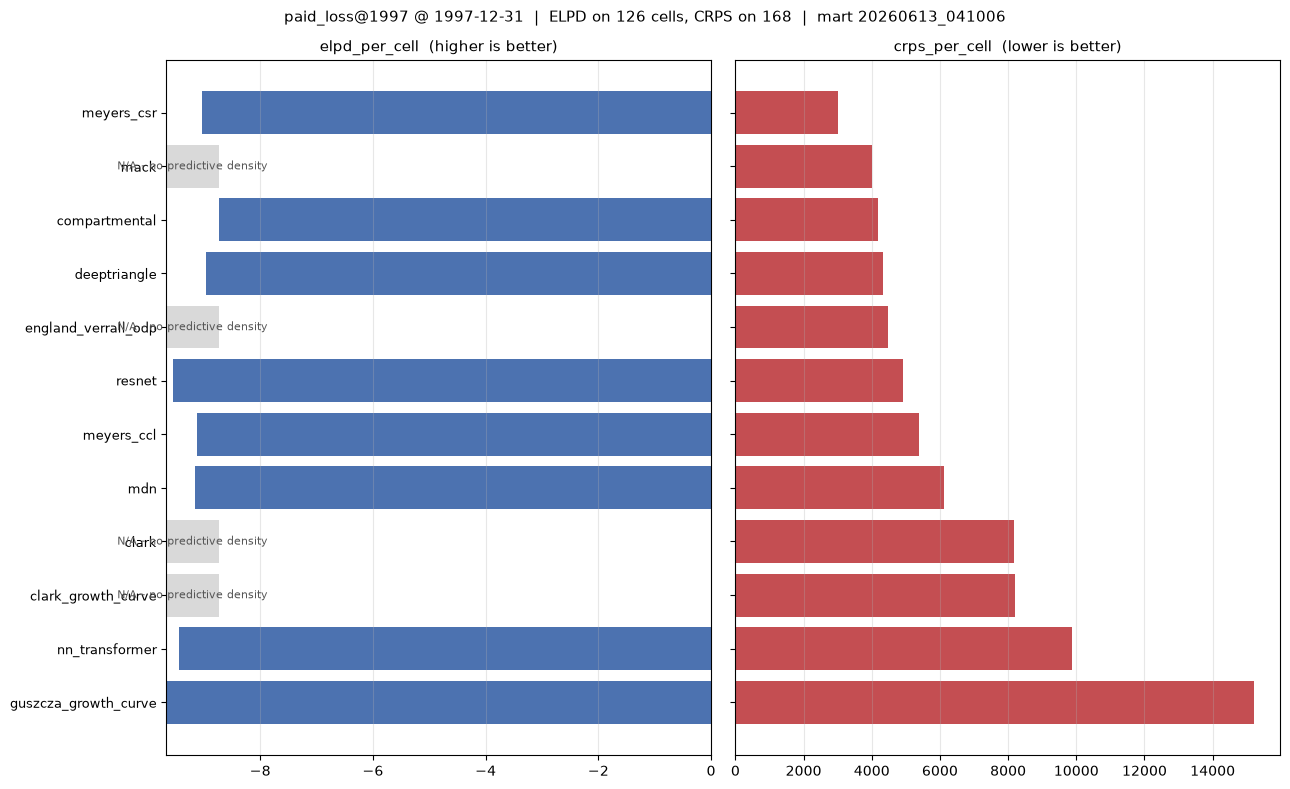

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 0.45 * len(board) + 2.6), sharey=True)
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))

for ax, col, direction in zip(
    axes, ["elpd_per_cell", "crps_per_cell"], ["higher is better", "lower is better"]
):
    vals = board.set_index("model").loc[order, col]
    have = vals.notna().to_numpy()
    v = pd.to_numeric(vals, errors="coerce").to_numpy(dtype=float)
    ax.barh(y[have], v[have], color="#4c72b0" if col.startswith("elpd") else "#c44e52")
    if (~have).any():
        # N/A is drawn as an explicit band, never omitted and never plotted as 0:
        # 0 is the best value in BOTH columns.
        lo, hi = np.nanmin(v), np.nanmax(v)
        span = hi - lo if hi > lo else abs(hi) or 1.0
        for yy in y[~have]:
            ax.barh(yy, span, left=min(lo, 0), color="#d9d9d9")
            ax.text(
                min(lo, 0) + span / 2,
                yy,
                "N/A - no predictive density",
                ha="center",
                va="center",
                fontsize=8,
                color="#555555",
            )
    ax.set_yticks(y, order, fontsize=9)
    ax.set_title(f"{col}  ({direction})", fontsize=11)
    ax.axvline(0, color="black", lw=0.6)
    ax.grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  ELPD on {panel.n_cells_for('elpd')} cells, "
    f"CRPS on {panel.n_cells_for('crps')}  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

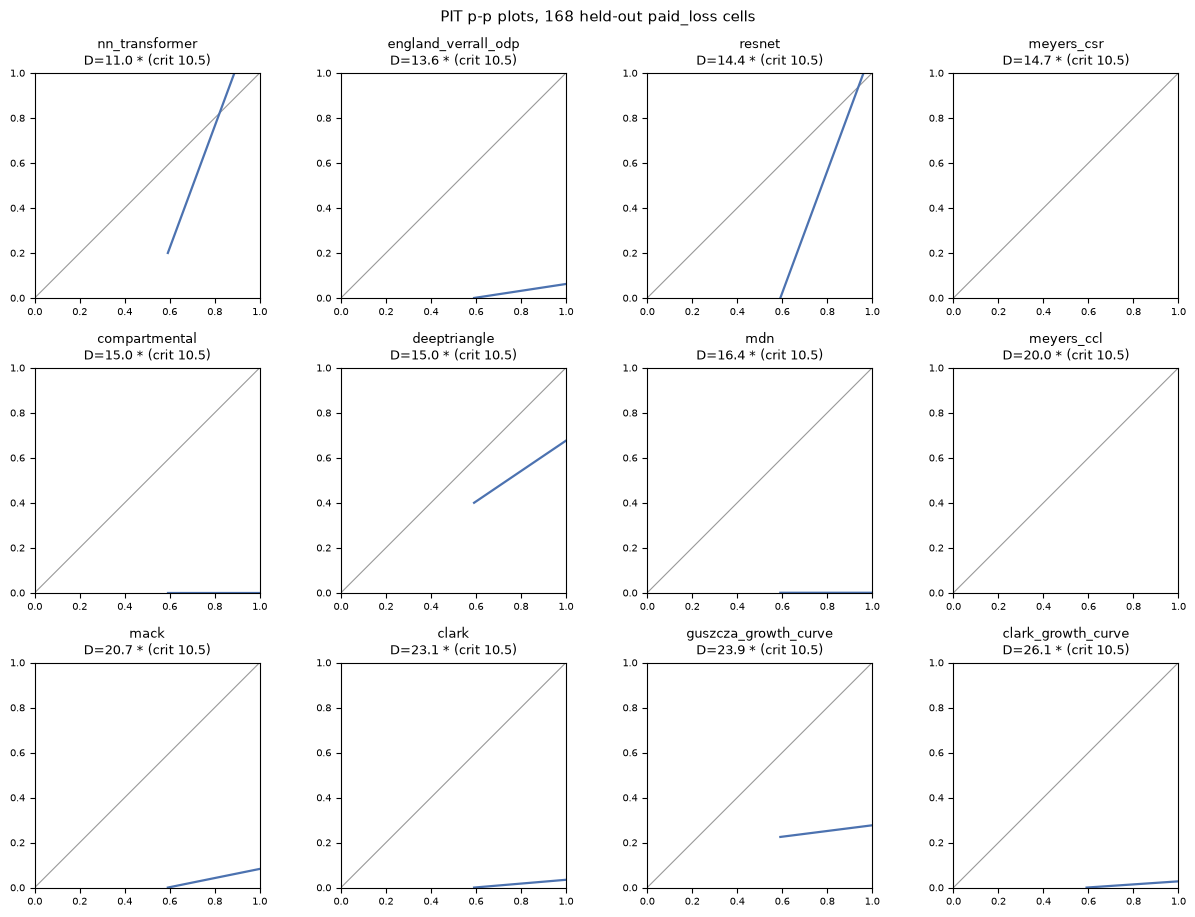

In [21]:
models = ks.sort_values("D x 100")["model"].tolist()
ncol = 4
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.1 * nrow), squeeze=False)
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    ax.plot([0, 1], [0, 1], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    flag = "" if r["passes"] else " *"
    ax.set_title(f"{m}\nD={r['D x 100']:.1f}{flag} (crit {r['critical 5% x 100']:.1f})", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells", fontsize=11)
fig.tight_layout()
plt.show()

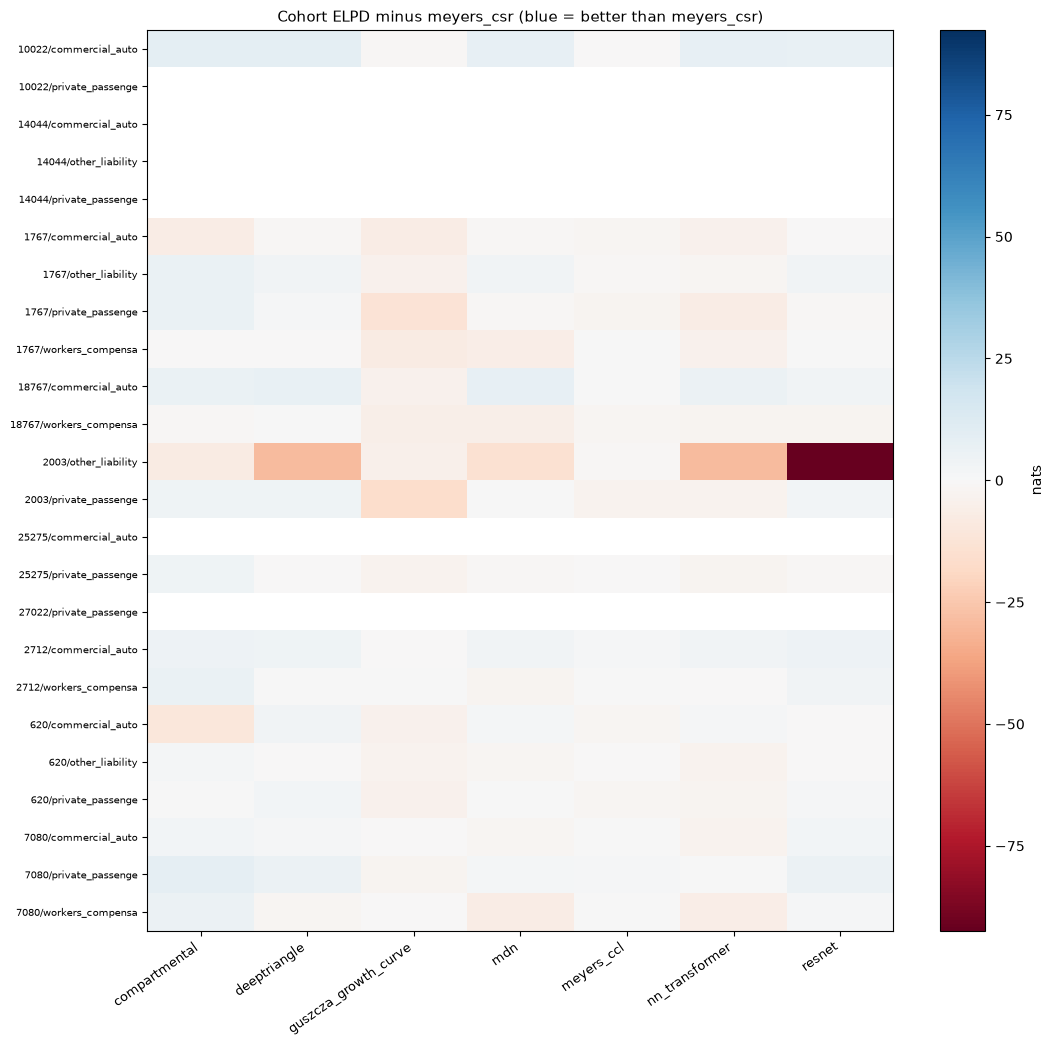

In [22]:
fig, ax = plt.subplots(figsize=(11, 0.34 * len(diff) + 2.4))
data = diff[sorted(diff.columns)]
im = ax.imshow(
    data.to_numpy(dtype=float),
    aspect="auto",
    cmap="RdBu",
    vmin=-np.nanmax(np.abs(data.to_numpy(dtype=float))),
    vmax=np.nanmax(np.abs(data.to_numpy(dtype=float))),
)
ax.set_xticks(range(data.shape[1]), data.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(data.shape[0]), data.index, fontsize=7)
ax.set_title(f"Cohort ELPD minus {REFERENCE} (blue = better than {REFERENCE})", fontsize=11)
fig.colorbar(im, ax=ax, label="nats")
fig.tight_layout()
plt.show()

## Appendix A: the multiline entries

`sur`, `copula_glm` and `nn_transformer_ml` subclass **neither** held-out mixin, so they
cannot appear in the ELPD or CRPS column at all. They are the entries that model
dependence *across lines*, which is the one thing every model on the board above
structurally cannot do - the single-line transformer's per-line draws are independent -
so they are compared here at the ultimate level instead, one fit per company over that
company's screened lines.

`nn_transformer_ml` is omitted on measured cost: its autoregressive rollout samples line
by line per calendar diagonal, and a single pooled fit on this 10-company panel ran past
10 minutes without completing. Its published results are in notebook 02 and in
`analysis/results/compare_gallery*.csv`.

In [23]:
ml_rows, corr_rows, ml_failures = [], [], []
t0 = time.perf_counter()
for company, lines in PANEL.items():
    ce = tri.expr
    ctri = tri.filter(ce.company_code == company)
    for name, kwargs in [("sur", {}), ("copula_glm", dict(dev_effect="factor"))]:
        try:
            entry = gallery.fit(name, ctri, loss_field=FIELD, as_of=AS_OF, **kwargs)
        except Exception as exc:
            # sur's FGLS and copula_glm's bootstrap each have documented family
            # limits; a refusal is a result, not a crash.
            ml_failures.append(dict(model=name, company_code=company, error=repr(exc)[:180]))
            continue
        pred = entry.predict(seed=SEED_DRAW)
        outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
        labels = pred.targets["label"].astype(str).tolist()
        i = labels.index("total") if "total" in labels else len(labels) - 1
        ml_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(pred.mean()[i]),
                sd=float(pred.std()[i]),
                realized_total=outcome[i],
                pct_error=100.0 * (pred.mean()[i] - outcome[i]) / outcome[i],
                outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
            )
        )
        # The quantity the single-line entries cannot produce.
        corr = entry.pooled_corr_ if name == "sur" else entry.corr_
        off = corr[np.triu_indices_from(corr, k=1)]
        corr_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                mean_cross_line_corr=float(np.mean(off)),
                max_abs=float(np.max(np.abs(off))),
            )
        )
        del entry
print(
    f"{len(ml_rows)} multiline fits in {time.perf_counter() - t0:.1f}s; {len(ml_failures)} refusals"
)
for f in ml_failures:
    print("  ", f)
ml = pd.DataFrame(ml_rows)
display(ml.round(2))
display(
    pd.DataFrame(corr_rows)
    .groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        mean_cross_line_corr=("mean_cross_line_corr", "mean"),
        max_abs=("max_abs", "max"),
    )
    .round(3)
)

16 multiline fits in 6.4s; 4 refusals
   {'model': 'copula_glm', 'company_code': '10022', 'error': 'ValueError(\'1 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}
   {'model': 'copula_glm', 'company_code': '14044', 'error': 'ValueError(\'11 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left '}
   {'model': 'copula_glm', 'company_code': '25275', 'error': 'ValueError(\'16 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left '}
   {'model': 'copula_glm', 'company_code': '27022', 'error': 'ValueError(\'10 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: i

,model,company_code,n_lines,predicted_total,sd,realized_total,pct_error,outcome_pct
0,sur,10022,2,70264.14,882.17,69390.0,1.26,15.95
1,sur,14044,3,47159.45,574.75,46818.0,0.73,28.07
2,sur,1767,4,99018863.69,618282.02,97520034.0,1.54,0.77
3,copula_glm,1767,4,99178074.50,655611.33,97520034.0,1.70,0.19
4,sur,18767,2,266101.25,3508.49,252556.0,5.36,0.01
5,copula_glm,18767,2,274192.13,14667.85,252556.0,8.57,0.86
6,sur,2003,2,12884865.96,177022.73,12666165.0,1.73,10.22
7,copula_glm,2003,2,13069064.73,343568.79,12666165.0,3.18,9.60
8,sur,25275,2,98255.03,1108.12,102990.0,-4.60,100.00
9,sur,27022,2,65308.82,1038.25,62222.0,4.96,0.19


,companies,mean_cross_line_corr,max_abs
model,,,
copula_glm,6,0.062,0.634
sur,10,0.056,0.588


## Appendix B: the same machinery on `reported_loss`

`paid_loss` is the headline field because three entries on the board require it -
`copula_glm`'s lognormal marginals cannot take a negative reported increment, and
`meyers_csr` / `england_verrall_odp` / `clark` are paid models by construction. But
`meyers_ccl` is a *reported*-loss model in the monograph, and the paid board under-sells
it.

So: the same 25 cohorts, the same `HoldoutCells` objects (built with both fields
precisely so this costs nothing extra), `field="reported_loss"` - and a **separate panel
and separate board**, because `align_panel` refuses to mix tasks. Summing the densities
of two different quantities into one number would still print.

This is deliberately not extended to the rest of the gallery: reported loss net of bulk
can decrease, which neither the ODP quasi-likelihood nor a lognormal increment accepts,
and a second full pass would cost another half hour.

In [24]:
if RUN_REPORTED_APPENDIX:
    rep_forecasts, rep_seconds = [], {}
    for name in ["meyers_ccl", "meyers_csr"]:
        t0 = time.perf_counter()
        for key in COHORTS:
            try:
                entry = gallery.fit(
                    name,
                    sub[key],
                    loss_field="reported_loss",
                    as_of=AS_OF,
                    seed=SEED_FIT,
                    parallel_chains=4,
                )
            except Exception as exc:
                rep_forecasts.append(
                    CohortForecast.unavailable(
                        model=name,
                        task="reported_loss@1997",
                        cells=cells[key],
                        field="reported_loss",
                        density_reason="fit_failed",
                        draws_reason="fit_failed",
                        detail=f"{type(exc).__name__}: {exc}"[:150],
                    )
                )
                continue
            rep_forecasts.append(
                forecast_for(name, entry, key, field="reported_loss", task="reported_loss@1997")
            )
            del entry
        rep_seconds[name] = round(time.perf_counter() - t0, 1)
        print(f"{name:14s} {rep_seconds[name]:6.1f}s", flush=True)
    rep_panel = align_panel(rep_forecasts, units=tri.meta.units)
    print()
    print(repr(rep_panel))
    rep_board = gallery.leaderboard(rep_panel)
    display(
        rep_board[
            [
                "model",
                "n_cells_elpd",
                "elpd",
                "elpd_per_cell",
                "min_ess_kish",
                "n_cells_crps",
                "crps",
                "crps_per_cell",
            ]
        ].round(3)
    )
else:
    rep_seconds = {}
    print("reported appendix skipped (RUN_REPORTED_APPENDIX = False)")

meyers_ccl       63.3s


meyers_csr       67.1s



ForecastPanel(reported_loss@1997 @ 1997-12-31, 2 models, 25 cohorts | elpd: 175 cells over ['meyers_ccl', 'meyers_csr'] | crps: 175 cells over ['meyers_ccl', 'meyers_csr'] | dropped=0)


,model,n_cells_elpd,elpd,elpd_per_cell,min_ess_kish,n_cells_crps,crps,crps_per_cell
0,meyers_ccl,175,-1435.422,-8.202,254.261,175,843382.194,4819.327
1,meyers_csr,175,-1423.156,-8.132,354.15,175,726509.575,4151.483


## What this notebook does not claim

1. **It is a demonstration, not a study.** 10 companies, 25 cohorts, 175 held-out cells,
   one cutoff, one field. Rankings on a panel this small move with the panel. The
   evidence is the 200-company retrospectives in `analysis/results/` and notebook 02.
2. **The cohorts are not a random sample of the mart.** They passed the Meyers stability
   screens and were then filtered to companies with no negative paid increment anywhere
   in the training slice, so `england_verrall_odp` could stay on the board without
   deleting cohorts from everyone else. Well-behaved data flatters every model here, and
   flatters the ones with the strongest positivity assumptions most.
3. **The NN entries run cut down.** 120 epochs and 5 ensemble members against the
   published study's 400 epochs, and their held-out density averages over the ensemble
   members - so `n_draws_density_min` reads 5 against Stan's 10,000 and `min_ess_kish`
   sits near it. ELPD is the same estimand at any draw budget; its Monte Carlo error is
   not, and on those rows it is large.
4. **`guszcza_growth_curve` and `compartmental` run at reduced budgets** (4x1000 rather
   than 4x2500) and `compartmental` at the harness's relaxed sampler
   (`target_accept=0.9`, `max_treedepth=12`, not the monograph's 0.99 / 15). Same
   estimands, more Monte Carlo error, and for compartmental a small number of divergent
   transitions the monograph settings would remove.
5. **The scored diagonal was chosen so the NN family could be scored at all.** Origins
   1990-1997 rather than 1988-1997 is a defensible choice, demonstrated live above, but
   it is a choice, and it costs the two deepest development lags - which are exactly
   where a growth-curve or CSR-style model is most distinctive.
6. **No stacking.** `kernels.stacking` needs a weights panel at an earlier cutoff plus an
   evaluation panel at the later one, which means fitting every density member twice.
   That belongs in its own notebook once this leaderboard is settled.

In [25]:
timings = (
    pd.DataFrame(
        [
            {"entry": k, "seconds": v, "seconds_per_cohort": round(v / len(COHORTS), 2)}
            for k, v in fit_seconds.items()
        ]
        + [
            {
                "entry": f"{k} (reported)",
                "seconds": v,
                "seconds_per_cohort": round(v / len(COHORTS), 2),
            }
            for k, v in rep_seconds.items()
        ]
    )
    .sort_values("seconds", ascending=False)
    .reset_index(drop=True)
)
display(timings)
print(
    f"total fitting: {timings['seconds'].sum() / 60:.1f} min "
    f"(+ {sum(compile_seconds.values()) / 60:.1f} min Stan compilation)"
)
print()
print("mart publish_id ", PUBLISH_ID)
print("ELPD fingerprint", panel.elpd_fingerprint, "|", panel.n_cells_for("elpd"), "cells")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)

,entry,seconds,seconds_per_cohort
0,compartmental,686.1,27.44
1,guszcza_growth_curve,311.1,12.44
2,nn_transformer,77.3,3.09
3,meyers_csr,73.1,2.92
4,meyers_ccl,72.6,2.90
5,meyers_csr (reported),67.1,2.68
6,clark_growth_curve,66.6,2.66
7,meyers_ccl (reported),63.3,2.53
8,england_verrall_odp,61.4,2.46
9,deeptriangle,46.0,1.84


total fitting: 26.6 min (+ 0.0 min Stan compilation)

mart publish_id  20260613_041006
ELPD fingerprint 0bd1e6212c5c56f2 | 126 cells
CRPS fingerprint 468d769145503ba4 | 168 cells
ibnr             0.5.0
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.4.6 2.3.3
